In [1]:
"""Test transmitted scattering of rough surfaces"""
import sys
sys.path.append('../../../')
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import scipy.constants as sci_const
import matplotlib.pyplot as plt

from mores.interface.IEM_downward import Mue_downward_IEMs
from mores.interface.AIEM_downward import Mue_downward_AIEMs

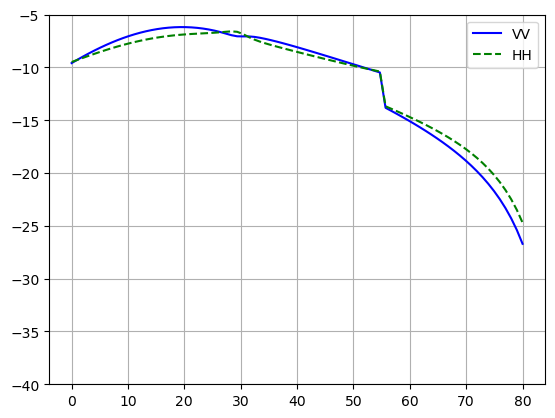

In [31]:
f = 1e9
kdel = 0.2
kcor = 1.0
epsr = 4 - 0.5j
c = sci_const.speed_of_light
Lambda = c / f
k = 2 * np.pi / Lambda

delta = kdel / k
corr_len = kcor / k

theta_i = 40
theta_ts = np.linspace(0, 80, 80)
phi_t = 20

N = len(theta_ts)
vvs = np.zeros(N)
hhs = np.zeros(N)
for i in range(N):
    theta_t = theta_ts[i]
    Mue = Mue_downward_AIEMs(f, (theta_t, phi_t), (theta_i, 0), epsr, delta, corr_len, spectrum='exp', x=1.5, shadow_flag=False)
    vvs[i] = 10*np.log10(4*np.pi * Mue[0, 0])
    hhs[i] = 10*np.log10(4*np.pi * Mue[1, 1])


# show
fig, ax = plt.subplots()
ax.plot(theta_ts, vvs, 'b-', label='VV')
ax.plot(theta_ts, hhs, 'g--', label='HH')
ax.grid()
ax.set_ylim(-40, -5)
plt.legend()
plt.show()

In [33]:
np.math.factorial(5)

120